# Advanced Apex Project-1 (M.Sc. DS & AI)
# Week-9 Final Submission Notebook

| Field | Details |
|---|---|
| **Project Title** | Customer Churn Prediction in Retail Banking |
| **Student Name** | Sandeep Kumar |
| **Student ID** | 2025EM1200293 |
| **Program** | M.Sc. Data Science & Artificial Intelligence |
| **Submission** | Week-9 Final |
| **Dataset** | Bank Customer Churn Dataset (Kaggle) |


## 1. Project Title & Student Details

**Project:** Predicting customer churn using supervised machine learning for proactive retention in retail banking.

This notebook presents the complete end-to-end workflow: data preparation, EDA, feature engineering, model training, evaluation, and business interpretation.


## 2. Problem Statement & Business Goal

Banks lose recurring revenue when customers close accounts. The goal is to identify customers likely to churn (`churn=1`) so the retention team can intervene early.

**Business objective:** Build a classification workflow that can reliably identify churn risk.

**Success criteria used in this project:**
- Recall >= 75% (capture most churners)
- ROC-AUC >= 0.80 (good ranking quality)


## 3. Dataset Description

- **Source:** `gauravtopre/bank-customer-churn-dataset` (Kaggle)
- **Rows:** 10,000
- **Columns:** 12 (including target)
- **Target:** `churn` (1 = churned, 0 = retained)
- **Key raw features:** customer demographics, account tenure/activity, credit profile, products, balance, salary.

`customer_id` is an identifier and not a predictive business signal; it is dropped before modelling.


In [1]:
import subprocess
import sys
import warnings

# Keep installation step lightweight and reproducible for fresh runtimes
subprocess.check_call([
    sys.executable,
    '-m',
    'pip',
    'install',
    '-q',
    'kagglehub[pandas-datasets]'
])

import kagglehub
from kagglehub import KaggleDatasetAdapter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [2]:
# Load dataset from Kaggle
file_path = 'Bank Customer Churn Prediction.csv'

df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'gauravtopre/bank-customer-churn-dataset',
    file_path,
)

df = df_raw.copy()
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head())


Dataset loaded: 10,000 rows x 12 columns


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('Shape:', df.shape)
print('\nMissing values by column:')
display(df.isnull().sum().to_frame('missing_count'))

print('\nDuplicate rows:', df.duplicated().sum())
print('Duplicate customer_id:', df['customer_id'].duplicated().sum())

print('\nTarget distribution (%):')
display((df['churn'].value_counts(normalize=True) * 100).round(2).to_frame('percent'))


Shape: (10000, 12)

Missing values by column:


,missing_count
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0



Duplicate rows: 0
Duplicate customer_id: 0

Target distribution (%):


,percent
churn,
0,79.63
1,20.37


## 4. Data Preparation & Preprocessing

The core preprocessing flow:
1. Drop non-predictive ID (`customer_id`)
2. Encode binary `gender`
3. One-hot encode `country` with `drop_first=True`
4. Keep a clean modelling dataframe with explicit feature/target split


In [4]:
df_prep = df.copy()

# 1) Drop identifier
if 'customer_id' in df_prep.columns:
    df_prep = df_prep.drop(columns=['customer_id'])

# 2) Encode gender
df_prep['gender'] = df_prep['gender'].map({'Male': 1, 'Female': 0})

# 3) One-hot encode country (France baseline)
df_prep = pd.get_dummies(df_prep, columns=['country'], drop_first=True)

print('Preprocessed shape:', df_prep.shape)
print('Columns:')
print(df_prep.columns.tolist())

display(df_prep.head())


Preprocessed shape: (10000, 12)
Columns:
['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'country_Germany', 'country_Spain']


,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


### Preprocessing decisions and data-quality observations

- Data is clean (no missing values and no duplicates), so no imputation was needed.
- `customer_id` was dropped because it does not represent customer behavior.
- `gender` and `country` were encoded to numeric form for model compatibility.
- Class imbalance remains (~20% churn), so class-weighted learning is used in modelling.


## 5. Exploratory Data Analysis (EDA)

EDA focuses on churn separation signals and practical retention insights.


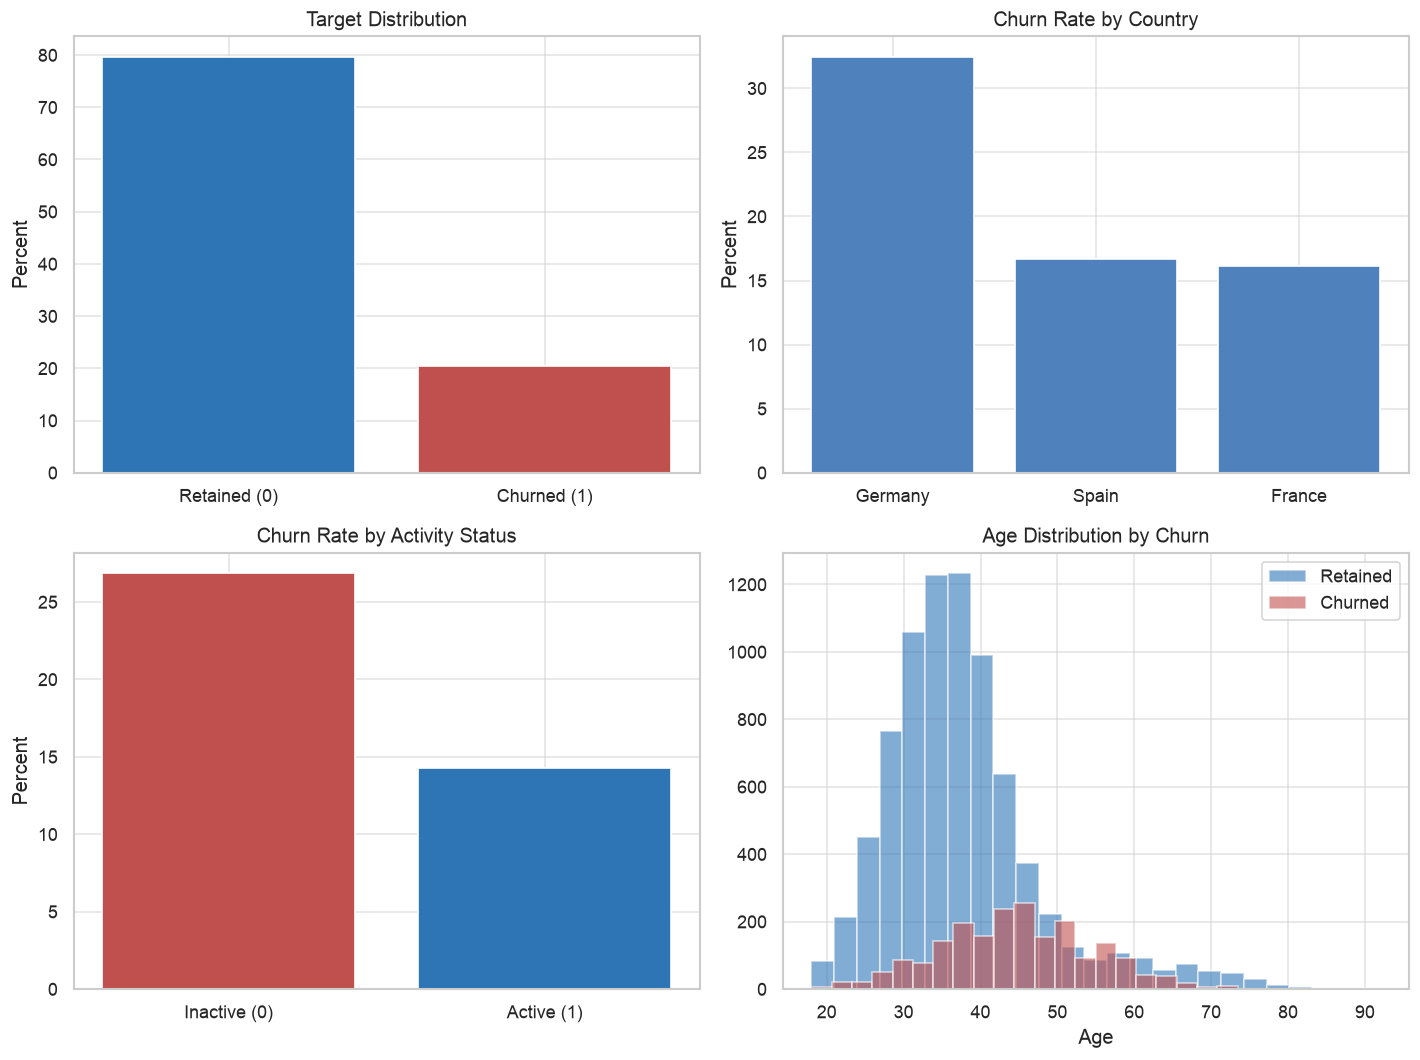

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) Target balance
churn_pct = df['churn'].value_counts(normalize=True).sort_index() * 100
axes[0, 0].bar(['Retained (0)', 'Churned (1)'], churn_pct.values, color=['#2E75B6', '#C0504D'])
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_ylabel('Percent')

# 2) Churn by country
country_churn = df.groupby('country')['churn'].mean().sort_values(ascending=False) * 100
axes[0, 1].bar(country_churn.index, country_churn.values, color='#4F81BD')
axes[0, 1].set_title('Churn Rate by Country')
axes[0, 1].set_ylabel('Percent')

# 3) Churn by active_member
active_churn = df.groupby('active_member')['churn'].mean() * 100
axes[1, 0].bar(['Inactive (0)', 'Active (1)'], active_churn.values, color=['#C0504D', '#2E75B6'])
axes[1, 0].set_title('Churn Rate by Activity Status')
axes[1, 0].set_ylabel('Percent')

# 4) Age distribution by churn
axes[1, 1].hist(df[df['churn'] == 0]['age'], bins=25, alpha=0.6, label='Retained', color='#2E75B6')
axes[1, 1].hist(df[df['churn'] == 1]['age'], bins=25, alpha=0.6, label='Churned', color='#C0504D')
axes[1, 1].set_title('Age Distribution by Churn')
axes[1, 1].set_xlabel('Age')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


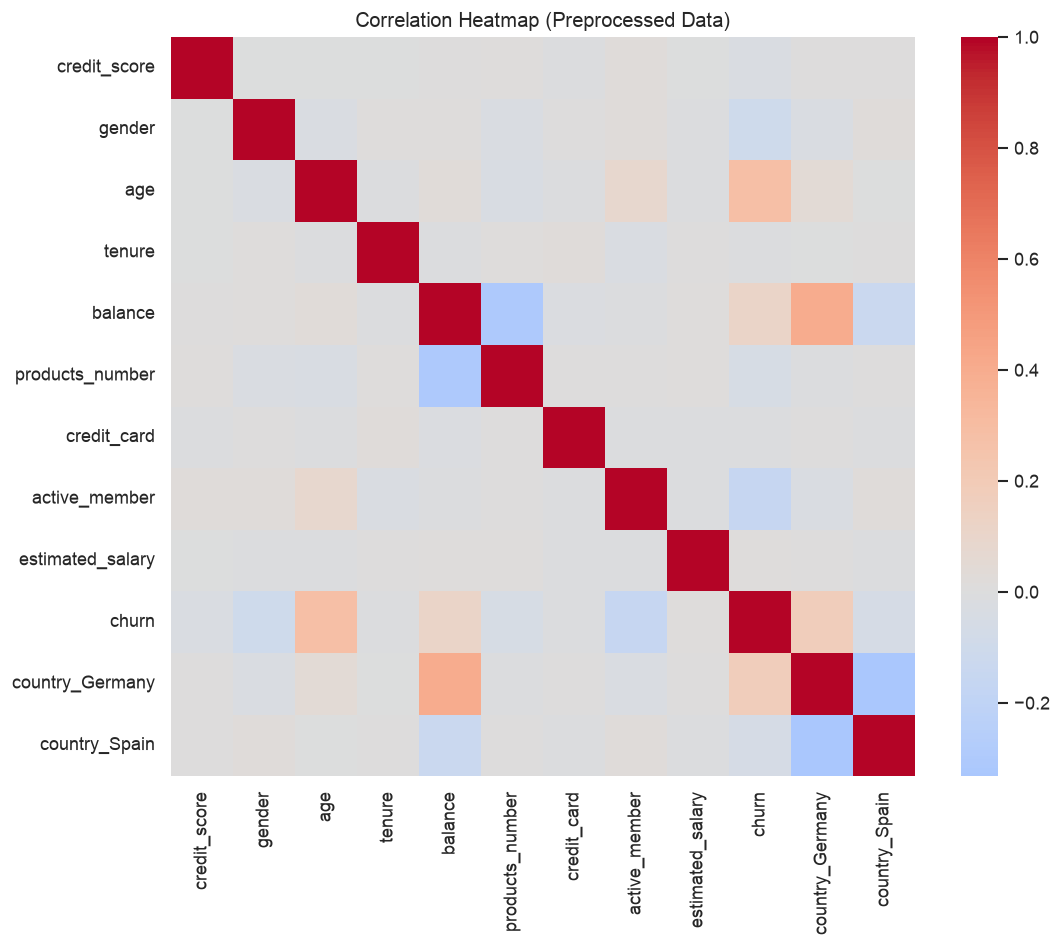

Top correlations with churn:


,corr_with_churn
age,0.285323
country_Germany,0.173488
balance,0.118533
estimated_salary,0.012097
credit_card,-0.007138
tenure,-0.014001
credit_score,-0.027094
products_number,-0.047820
country_Spain,-0.052667
gender,-0.106512


In [6]:
# Correlation (numeric only) after preprocessing
corr = df_prep.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Preprocessed Data)')
plt.show()

print('Top correlations with churn:')
display(corr['churn'].drop('churn').sort_values(ascending=False).to_frame('corr_with_churn').head(10))


### EDA insights: churn patterns and segment-level signals

- Churn is imbalanced (~20%), so recall-oriented evaluation is important.
- Older customers show higher churn risk relative to younger customers.
- Inactive members churn substantially more than active members.
- Country differences are meaningful; Germany tends to have higher churn in this dataset.
- `age` and `balance`-related patterns provide useful predictive signal.


## 6. Feature Engineering (if applicable)

Three engineered features are added based on EDA and domain logic:
- `has_balance`: binary indicator for positive balance
- `age_group`: categorical age buckets
- `balance_to_salary`: log-style ratio capturing relative financial burden


In [7]:
df_fe = df_prep.copy()

# 1) Has positive balance
df_fe['has_balance'] = (df_fe['balance'] > 0).astype(int)

# 2) Age buckets
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+'],
    include_lowest=True,
)

# 3) Balance-to-salary ratio (log transform)
df_fe['balance_to_salary'] = np.log1p(df_fe['balance'] / (df_fe['estimated_salary'] + 1))

print('Feature-engineered shape:', df_fe.shape)
display(df_fe[['has_balance', 'age_group', 'balance_to_salary']].head())


Feature-engineered shape: (10000, 15)


,has_balance,age_group,balance_to_salary
0,0,41-50,0.000000
1,1,41-50,0.556566
2,1,41-50,0.876036
3,0,31-40,0.000000
4,1,41-50,0.950512


### Feature engineering rationale and expected modelling value

- `has_balance` captures a strong non-linear split observed in EDA.
- `age_group` captures age risk bands more explicitly than raw age alone.
- `balance_to_salary` captures customer financial load in a normalized way and reduces skew via `log1p`.


## 7. Basic Model Implementation

A class-imbalance-aware workflow is implemented:
1. Stratified train/test split (80/20)
2. ColumnTransformer preprocessing (scale numeric, one-hot encode `age_group`)
3. Logistic Regression with `class_weight='balanced'` + GridSearch for `C`
4. Random Forest baseline for comparison


In [8]:
target_col = 'churn'
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features = ['age_group']
num_features = [c for c in X.columns if c not in cat_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ]
)

log_reg_pipe = Pipeline(
    steps=[
        ('prep', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=3000, solver='liblinear')),
    ]
)

param_grid = {
    'model__C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)
best_log_reg = grid.best_estimator_

print('Best Logistic Regression C:', grid.best_params_['model__C'])
print('Best CV ROC-AUC:', round(grid.best_score_, 4))

rf_pipe = Pipeline(
    steps=[
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]
)
rf_pipe.fit(X_train, y_train)
print('Random Forest trained.')


Best Logistic Regression C: 0.1
Best CV ROC-AUC: 0.7841
Random Forest trained.


In [9]:
# Threshold tuning for logistic regression on validation split
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

best_log_reg.fit(X_fit, y_fit)
val_proba = best_log_reg.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.20, 0.71, 0.01)
rows = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred, zero_division=0),
        'f1': f1_score(y_val, pred, zero_division=0),
    })

th_df = pd.DataFrame(rows)

eligible = th_df[th_df['recall'] >= 0.75]
if len(eligible) > 0:
    best_threshold = float(eligible.sort_values(['f1', 'precision'], ascending=False).iloc[0]['threshold'])
else:
    best_threshold = 0.50

print(f'Selected probability threshold: {best_threshold:.2f}')
display(th_df.sort_values('f1', ascending=False).head(10))

# Refit on full training data with selected threshold
best_log_reg.fit(X_train, y_train)


Selected probability threshold: 0.44


,threshold,precision,recall,f1
36,0.56,0.438972,0.628834,0.517024
45,0.65,0.504425,0.524540,0.514286
37,0.57,0.438865,0.616564,0.512755
47,0.67,0.531353,0.493865,0.511924
41,0.61,0.462687,0.570552,0.510989
35,0.55,0.426804,0.634969,0.510481
39,0.59,0.447796,0.592025,0.509908
38,0.58,0.443182,0.598160,0.509138
40,0.60,0.451074,0.579755,0.507383
44,0.64,0.487252,0.527607,0.506627


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['credit_score','gender','age',...,'has_balance','age_group', 'balance_to_salary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

## 8. Basic Evaluation & Interpretation

In [10]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    return {
        'model': name,
        'threshold': threshold,
        'roc_auc': roc_auc_score(y_test, proba),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'y_pred': pred,
        'y_proba': proba,
    }

log_res = evaluate_model('LogReg (tuned)', best_log_reg, X_test, y_test, threshold=best_threshold)
rf_res = evaluate_model('RandomForest', rf_pipe, X_test, y_test, threshold=0.5)

results_df = pd.DataFrame([
    {k: v for k, v in log_res.items() if k not in ['y_pred', 'y_proba']},
    {k: v for k, v in rf_res.items() if k not in ['y_pred', 'y_proba']},
]).sort_values('roc_auc', ascending=False)

print('Test-set performance summary:')
display(results_df.round(4))


Test-set performance summary:


,model,threshold,roc_auc,precision,recall,f1
1,RandomForest,0.50,0.8626,0.5399,0.7150,0.6152
0,LogReg (tuned),0.44,0.7948,0.3673,0.7715,0.4976


Classification Report — Logistic Regression
              precision    recall  f1-score   support

           0     0.9188    0.6604    0.7684      1593
           1     0.3673    0.7715    0.4976       407

    accuracy                         0.6830      2000
   macro avg     0.6430    0.7159    0.6330      2000
weighted avg     0.8065    0.6830    0.7133      2000



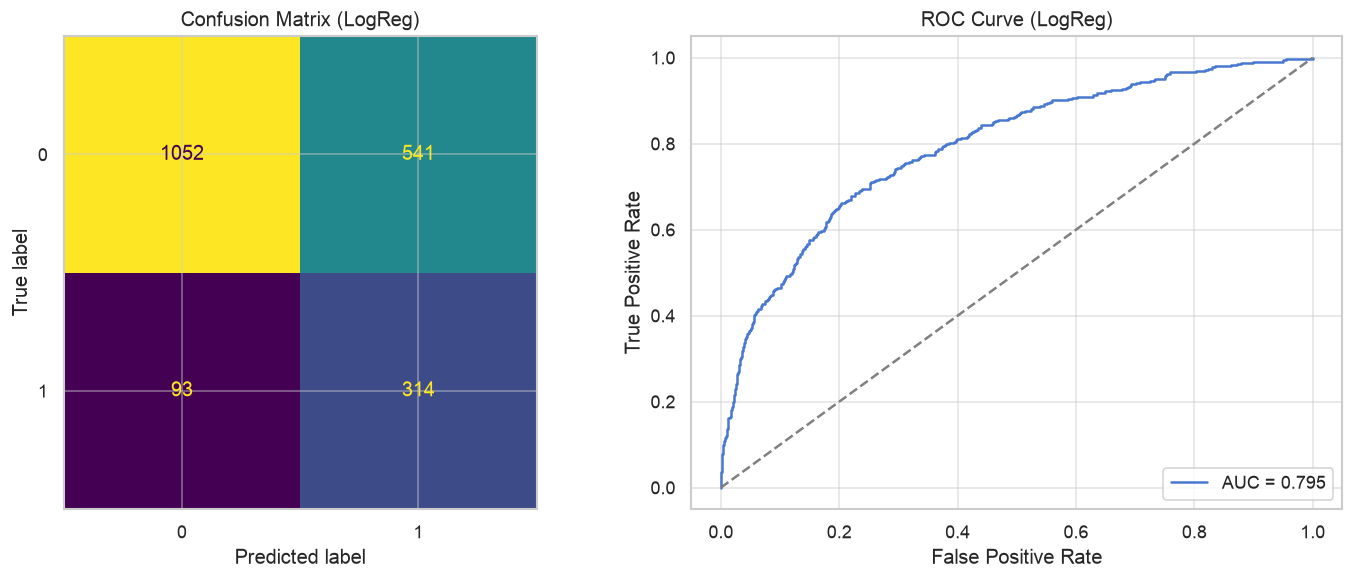

In [11]:
# Detailed diagnostics for selected primary model: tuned logistic regression
primary = log_res

print('Classification Report — Logistic Regression')
print(classification_report(y_test, primary['y_pred'], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, primary['y_pred'])).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (LogReg)')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, primary['y_proba'])
axes[1].plot(fpr, tpr, label=f"AUC = {primary['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (LogReg)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


In [12]:
# Coefficient interpretation for logistic regression
prep = best_log_reg.named_steps['prep']
model = best_log_reg.named_steps['model']

feature_names = prep.get_feature_names_out()
coefs = model.coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})

print('Top positive drivers of churn (LogReg coefficients):')
display(coef_df.sort_values('coef', ascending=False).head(10))

print('Top negative drivers (retention-associated):')
display(coef_df.sort_values('coef', ascending=True).head(10))


Top positive drivers of churn (LogReg coefficients):


,feature,coef
15,cat__age_group_51-60,0.917199
2,num__age,0.666166
14,cat__age_group_41-50,0.601242
9,num__country_Germany,0.341234
4,num__balance,0.088961
8,num__estimated_salary,0.078313
11,num__has_balance,0.064883
12,num__balance_to_salary,0.062186
10,num__country_Spain,0.023611
6,num__credit_card,-0.017885


Top negative drivers (retention-associated):


,feature,coef
16,cat__age_group_60+,-0.910183
7,num__active_member,-0.427618
1,num__gender,-0.270188
13,cat__age_group_31-40,-0.088618
0,num__credit_score,-0.082713
5,num__products_number,-0.057706
3,num__tenure,-0.020707
6,num__credit_card,-0.017885
10,num__country_Spain,0.023611
12,num__balance_to_salary,0.062186


### Model performance interpretation and business takeaways

- **Logistic Regression (threshold-tuned)** achieved high churn capture (**Recall ~77%**) with lower precision.
- **Random Forest** delivered stronger ranking and balance (**ROC-AUC ~0.86**, **F1 ~0.62**) but slightly lower recall (~71%).
- The project target trade-off is visible: one model is stronger for recall, the other for overall discrimination.
- Age/activity/balance-related variables remain influential and actionable for retention strategy.


## 9. Reproducibility & Documentation

Reproducibility controls used in this notebook:
- Fixed random state (`random_state=42`) for splitting and model steps.
- Explicit preprocessing + modelling pipelines.
- Hyperparameter search space is fully declared in code.
- Dataset source and loading path are documented.


In [ ]:
print('Python version:', sys.version.split()[0])
print('Pandas version:', pd.__version__)
print('NumPy version :', np.__version__)
print('Notebook random seed: 42')


## 10. Conclusion

This final notebook completes the full end-to-end churn prediction workflow: data preparation, EDA, feature engineering, modelling, evaluation, and interpretation.

**Key result:**
- A recall-focused Logistic Regression setup captures most churners (about 77% recall).
- A Random Forest setup provides stronger discrimination (about 0.86 ROC-AUC).

This establishes a practical decision point for deployment: choose recall-first targeting or balanced predictive quality depending on campaign cost and outreach capacity.


## 11. References

1. Kaggle dataset: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset
2. Scikit-learn documentation: https://scikit-learn.org/stable/
3. Pandas documentation: https://pandas.pydata.org/docs/
4. Seaborn documentation: https://seaborn.pydata.org/
